## loading the cleaned data sets 

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
pd.read_csv("../Data Analysis/final_cleaned_dataset.csv").head(5)

,TicketID,TicketReference,ClientID,PatientRef,CategoryID,PriorityID,Status,AssignedAgentID,CreatedAt,FirstResponseAt,...,Specialisms,Hub,DailyCapacity,IsActive_Agent,IsResolved,ResolutionNotesAvailable,FirstResponseAvailable,IsResolvedByStatus,FirstResponseHours,ResolutionHours
0,1,NB-2024-00001,70,PT-81496,5,3,Closed,111,2024-07-24 23:41:00,2024-07-25 02:27:00,...,"Complaint,Appointment Change,Document Request",Edinburgh,16,1,1,1,1,1,2.766667,58.900000
1,2,NB-2024-00002,51,PT-99051,2,1,Closed,32,2024-11-06 23:45:00,2024-11-07 01:09:00,...,"Document Request,Appointment Change,Insurance ...",Manchester,8,1,1,1,1,1,1.400000,4.983333
2,3,NB-2024-00003,53,PT-24869,3,3,Closed,57,2024-08-01 05:39:00,2024-08-01 09:58:00,...,"Complaint,Billing Issue,Insurance Query",Leeds,21,1,1,1,1,1,4.316667,32.933333
3,4,NB-2024-00004,11,PT-55537,1,2,Closed,22,2024-12-03 13:22:00,2024-12-03 14:47:00,...,"Billing Issue,Document Request,Appointment Change",Manchester,27,1,1,1,1,1,1.416667,18.166667
4,5,NB-2023-00005,70,PT-50539,3,2,Resolved,52,2023-02-11 03:56:00,2023-02-11 06:27:00,...,"Billing Issue,Insurance Query,Document Request",Leeds,26,1,1,1,1,1,2.516667,8.500000


In [4]:
final_df = pd.read_csv("../Data Analysis/final_cleaned_dataset.csv")
final_df.shape
final_df.dtypes


TicketID                      int64
TicketReference                 str
ClientID                      int64
PatientRef                      str
CategoryID                    int64
PriorityID                    int64
Status                          str
AssignedAgentID               int64
CreatedAt                       str
FirstResponseAt                 str
ResolvedAt                      str
SLADueAt                        str
SLABreached                   int64
Channel                         str
Description                     str
ResolutionNotes                 str
ClientName                      str
ClientType                      str
ContractTier                    str
AccountManagerID              int64
Region                          str
ContractStartDate               str
ContractEndDate                 str
SLACreditClause               int64
IsActive                      int64
AgentID                       int64
FullName                        str
TeamID                      

In [5]:
status_counts = final_df["Status"].value_counts()

print(status_counts)

Status
Closed            1984
Resolved          1317
Escalated           57
In Progress         52
Open                46
Pending Client      44
Name: count, dtype: int64


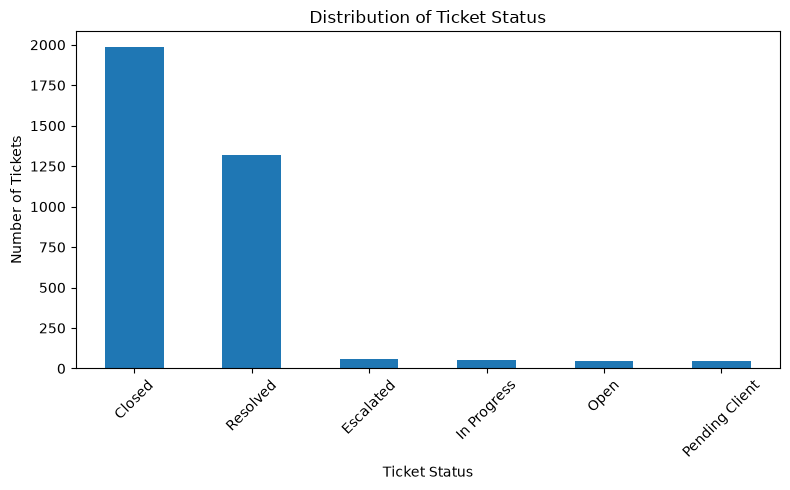

In [6]:
status_counts.plot(kind="bar",figsize=(8, 5),title="Distribution of Ticket Status")

plt.xlabel("Ticket Status")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Priority distribution 

PriorityID
1     258
2     833
3    1981
4     428
Name: count, dtype: int64


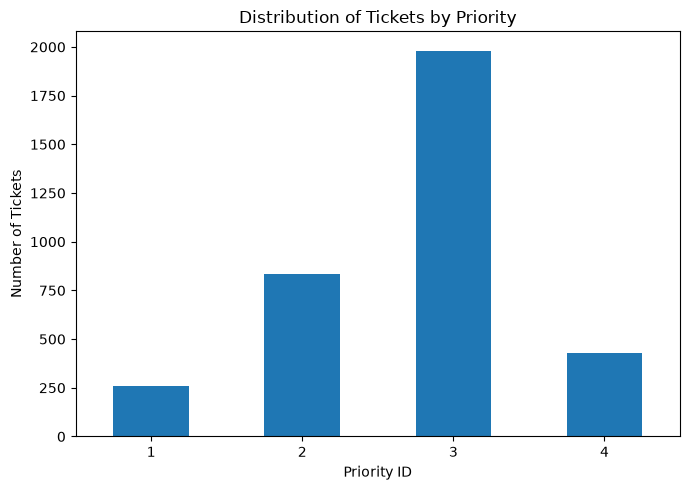

In [7]:
priority_counts = ( final_df["PriorityID"].value_counts().sort_index())

print(priority_counts)

priority_counts.plot(kind="bar",figsize=(7, 5),title="Distribution of Tickets by Priority")

plt.xlabel("Priority ID")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ticket Channels

Channel
Email     1221
Portal     977
Phone      905
Form       397
Name: count, dtype: int64


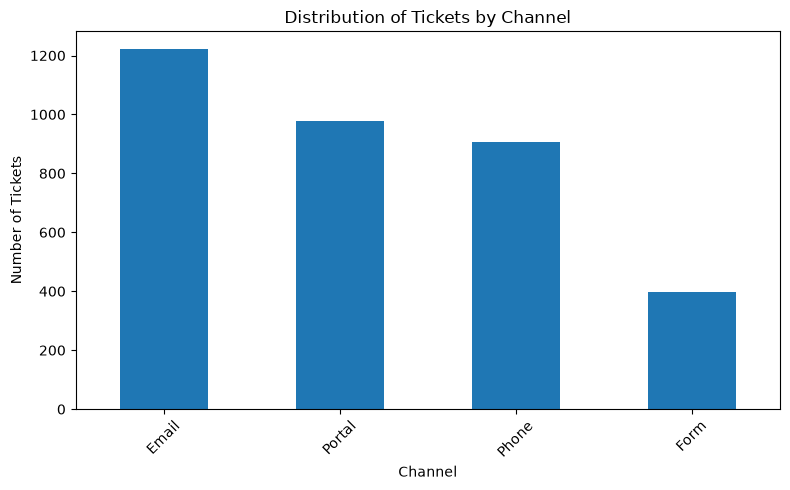

In [8]:
channel_counts = final_df["Channel"].value_counts()

print(channel_counts)

channel_counts.plot( kind="bar",figsize=(8, 5),title="Distribution of Tickets by Channel")

plt.xlabel("Channel")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### contract tiers

ContractTier
Standard      1662
Premium       1295
Enterprise     543
Name: count, dtype: int64


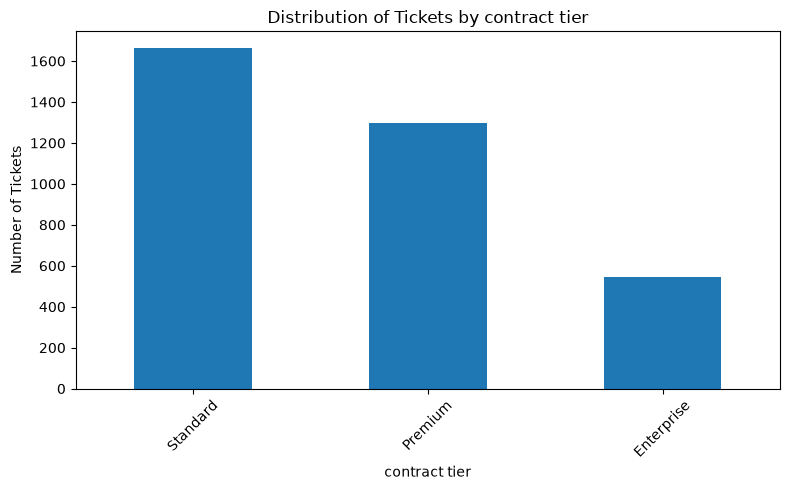

In [9]:
contract_counts = final_df["ContractTier"].value_counts()

print(contract_counts)

contract_counts.plot(kind="bar",figsize=(8, 5),title="Distribution of Tickets by contract tier")

plt.xlabel("contract tier")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### response and resolution times

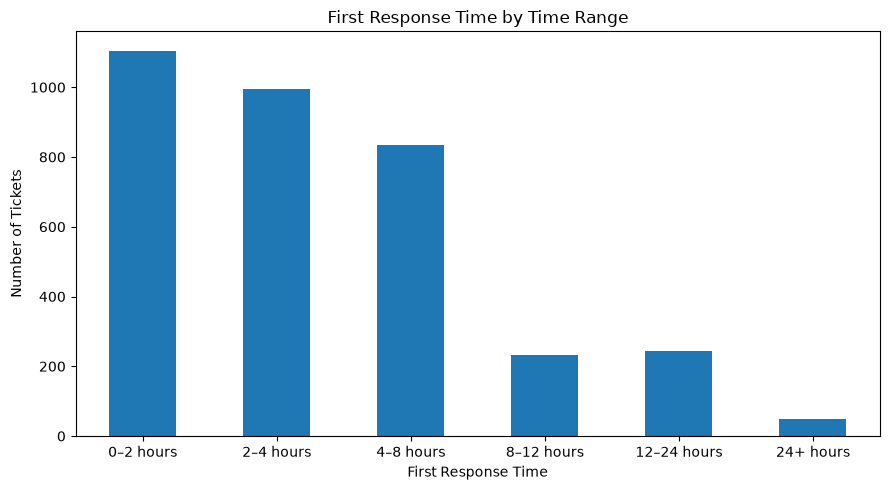

In [10]:
final_df[["FirstResponseHours", "ResolutionHours"]].describe()

response_bins = [0, 2, 4, 8, 12, 24, float("inf")]
response_labels = [
    "0–2 hours",
    "2–4 hours",
    "4–8 hours",
    "8–12 hours",
    "12–24 hours",
    "24+ hours"
]

response_groups = pd.cut(
    final_df["FirstResponseHours"],
    bins=response_bins,
    labels=response_labels,
    right=False
)

response_counts = response_groups.value_counts().reindex(response_labels)

response_counts.plot(
    kind="bar",
    figsize=(9, 5),
    title="First Response Time by Time Range"
)

plt.xlabel("First Response Time")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### SLA breaches

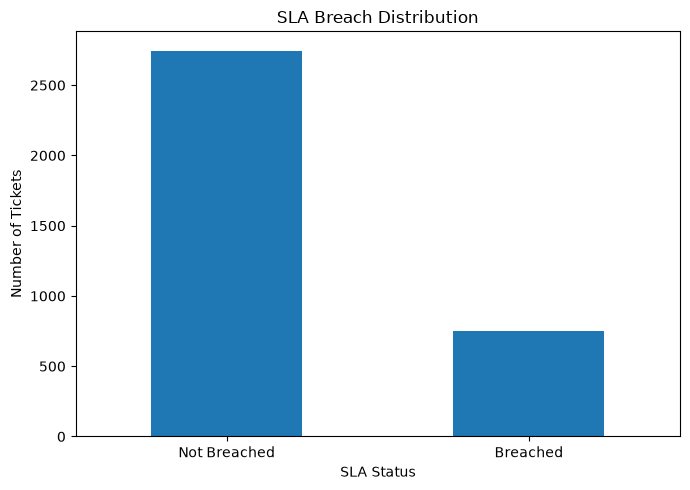

In [11]:
sla_counts = final_df["SLABreached"].value_counts().sort_index()

sla_counts.index = ["Not Breached", "Breached"]

sla_counts.plot(kind="bar",figsize=(7, 5),title="SLA Breach Distribution")

plt.xlabel("SLA Status")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### SLA breach rate by priority

In [15]:
# SLA breach rate by priority

priority_breach = pd.crosstab(final_df["PriorityID"], final_df["SLABreached"], normalize="index") * 100

priority_breach




SLABreached,0,1
PriorityID,,
1,71.317829,28.682171
2,79.831933,20.168067
3,78.495709,21.504291
4,79.906542,20.093458


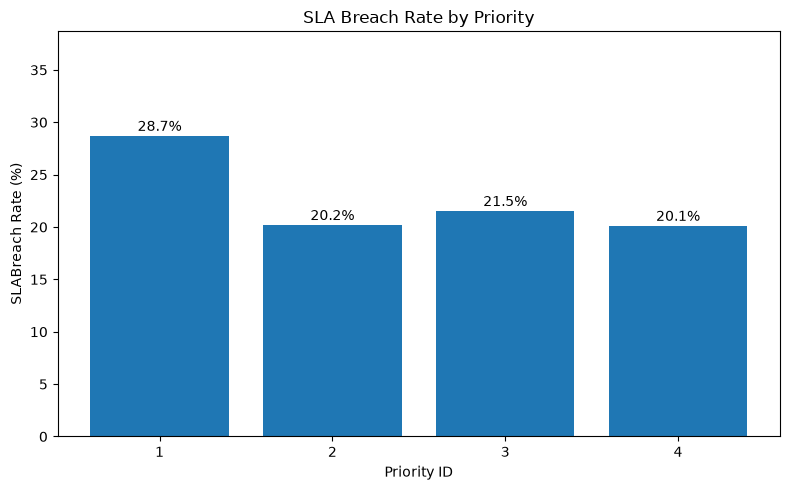

In [16]:
# Extract breach percentages
breach_rates = priority_breach[1]

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(breach_rates.index.astype(str),breach_rates.values)

plt.title("SLA Breach Rate by Priority")
plt.xlabel("Priority ID")
plt.ylabel("SLABreach Rate (%)")
plt.ylim(0, max(breach_rates.values) + 10)

# Add percentage labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2,height + 0.5,f"{height:.1f}%",ha="center")

plt.tight_layout()
plt.show()

### SLA brached by channel

In [19]:
# SLA breach rate by channel

channel_breach = ( final_df.groupby("Channel")["SLABreached"].mean().sort_values(ascending=False) * 100)

print(channel_breach)

Channel
Phone     23.867403
Form      22.418136
Portal    20.777892
Email     20.147420
Name: SLABreached, dtype: float64


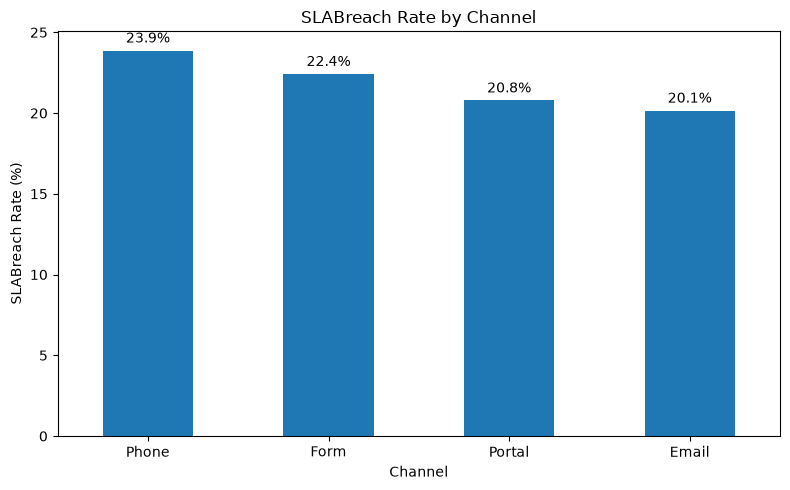

In [20]:
plt.figure(figsize=(8, 5))

ax = channel_breach.plot(kind="bar")

plt.title("SLABreach Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("SLABreach Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(channel_breach):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

### Contract tier 

In [21]:
contract_breach = (final_df.groupby("ContractTier")["SLABreached"].mean().sort_values(ascending=False) * 100)

print(contract_breach)

ContractTier
Standard      21.901324
Premium       21.389961
Enterprise    20.810313
Name: SLABreached, dtype: float64


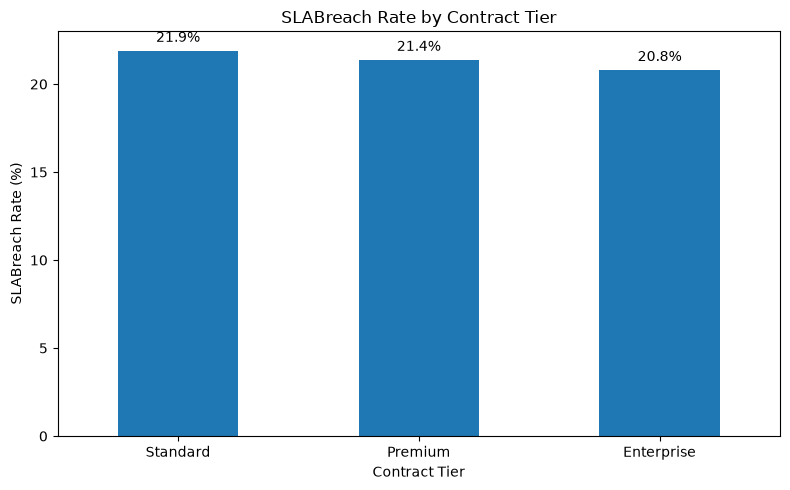

In [22]:
plt.figure(figsize=(8, 5))

ax = contract_breach.plot(kind="bar")

plt.title("SLABreach Rate by Contract Tier")
plt.xlabel("Contract Tier")
plt.ylabel("SLABreach Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(contract_breach):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

#### SLA Breach by Status

In [23]:
status_breach = (final_df.groupby("Status")["SLABreached"].mean().sort_values(ascending=False) * 100)

print(status_breach)

Status
Escalated         47.368421
Pending Client    40.909091
In Progress       32.692308
Open              32.608696
Closed            21.018145
Resolved          19.741838
Name: SLABreached, dtype: float64


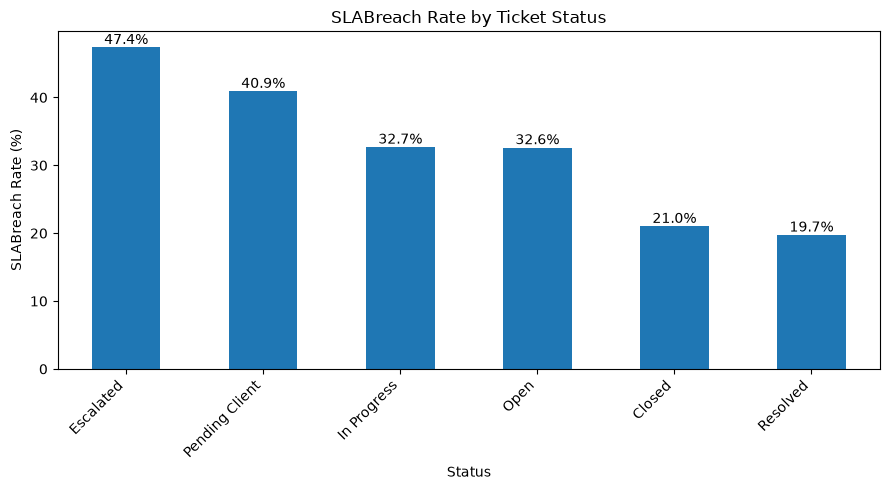

In [24]:
plt.figure(figsize=(9, 5))

ax = status_breach.plot(kind="bar")

plt.title("SLABreach Rate by Ticket Status")
plt.xlabel("Status")
plt.ylabel("SLABreach Rate (%)")
plt.xticks(rotation=45, ha="right")

for i, value in enumerate(status_breach):
    ax.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

### numerical analysis

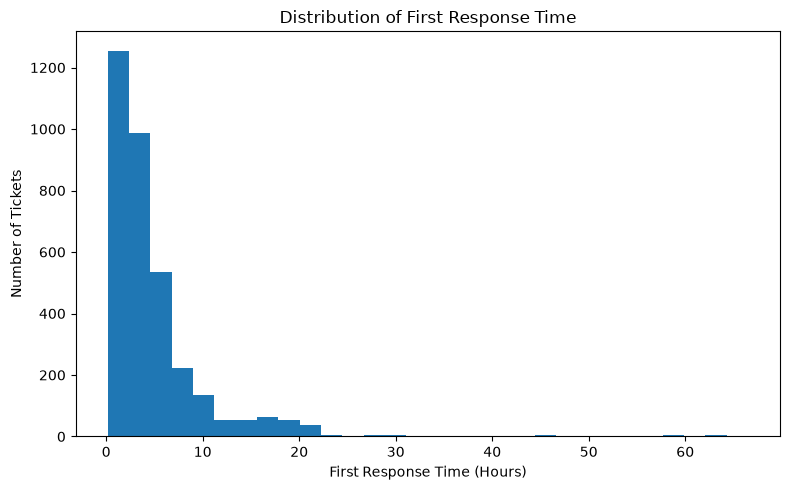

In [27]:
plt.figure(figsize=(8, 5))

plt.hist(final_df["FirstResponseHours"].dropna(), bins=30)

plt.title("Distribution of First Response Time")
plt.xlabel("First Response Time (Hours)")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

### Resolution time

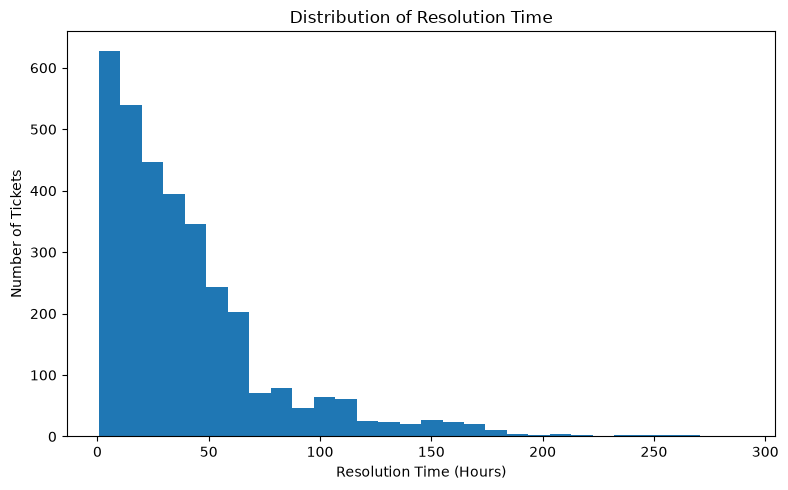

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(final_df["ResolutionHours"].dropna(), bins=30)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Time (Hours)")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.show()